## Preprocessing

Before running the model, you can either perform preprocessing by yourself or use the preprocessing functions provided in BLEND. Note that both adata and sc_adata should be stored in sparse matrix format.

In [1]:
import scanpy as sc
import blend
import anndata

adata = sc.read_h5ad('./mouse_brain.h5ad')
sc_adata = sc.read_h5ad('./sc_mousebrain.h5ad')

adata = blend.data_process(adata)
sc_adata = blend.data_process(sc_adata)
adata, sc_adata = blend.select_common_genes(adata, sc_adata)
adata = blend.minmax_scale_cells(adata)

Number of common genes: 13589
adata shape after filtering: (38767, 13589)
sc_adata shape after filtering: (17828, 13589)


Running BLEND_fit initializes the model and returns the necessary components, including the input data, the initialized matrices W, H, V, the single-cell reference matrix, the similarity matrix S, and the rank. The parameter setrank controls the dimension of the low-rank nonnegative matrix factorization. If you do not wish to specify it manually, you can set setrank=0, and the model will automatically estimate the rank.

In [2]:
data, W_initial, H_initial, sc_reference, V_initial, Similarity_matrix, rank = blend.BLEND_fit(spatial_data=adata, sc_data=sc_adata, setrank=20, device="cuda:0")

/home/lixuan/miniconda3/envs/blend_demo/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/lixuan/program/code_organization/BLEND_main/blend/main.py:16: ImplicitModificationWarning: Setting element `.obsm['X_norm']` of view, initializing view as actual.
  sc_data.obsm['X_norm'] = median_normalize(sc_data.X)


Iter 0: cost=4828374.000000, improvement=inf
Iter 50: cost=3516292.750000, improvement=1497.000000
Training finished in 18.74 seconds.


## Parameter Selection

We provide a parameter selection model to help users choose a suitable initial set of parameter values:

1. Run the blend.loss() function to calculate the loss values required by the parameter selection model.
2. Pass the calculated loss values to the blend.predict_parameter() function to obtain the predicted parameter combination and its corresponding probability.

If the predicted parameter values are still not suitable, the parameters can be further fine-tuned. Detailed parameter-tuning guidance is provided in the README.md file under the BLEND_manual folder.

In [3]:
percent, kl_loss = blend.loss(data, W_initial, H_initial, V_initial, Similarity_matrix, P=sc_reference, device="cuda:0")

reconstraction loss : tensor(4574620.5000, device='cuda:0', grad_fn=<AddBackward0>)
Laplacian loss : tensor(1254.7765, device='cuda:0', grad_fn=<TraceBackward0>)
kl loss : tensor(43025.6406, device='cuda:0', grad_fn=<SumBackward0>)


In [4]:
import joblib
import pandas as pd

saved_object = joblib.load("./parameter_classifier.joblib")

loaded_model = saved_object["model"]

result = blend.predict_parameter(
    loaded_model,
    kl_loss=kl_loss,
    percent=percent
)

print(result)

{'predicted_parameter': 'lambda=10, gamma=0.6', 'probability_lambda10_gamma06': np.float64(0.7017377927365066), 'probability_lambda5_gamma03': np.float64(0.2982622072634934)}


## Model

By running the fit function, you obtain the final nonnegative matrix factorization results. The hyperparameters lamb, alpha, and weight can be adjusted by the user. We provide two commonly used parameter combinations:

lamb=10, alpha=13, weight=0.6; lamb=5, alpha=13, weight=0.3

You may also set max_iter to control the maximum number of optimization iterations. For reference, processing data with ~60,000 cells typically takes only a few minutes.

In [5]:
res = blend.fit(data, W_initial, H_initial, V_initial, Similarity_matrix, P=sc_reference, lamb=10, alpha=13, rank=rank, weight=0.6, max_iter=600, device="cuda:0")
W = res['W']

Iter 0: cost=5135985.000000, improvement=inf
Iter 50: cost=3356152.500000, improvement=1415.500000
Iter 100: cost=3315032.500000, improvement=578.250000
Iter 150: cost=3290605.750000, improvement=424.500000
Iter 200: cost=3271896.500000, improvement=329.500000
Iter 250: cost=3257322.250000, improvement=260.500000
Iter 300: cost=3245643.750000, improvement=211.250000
Iter 350: cost=3236116.000000, improvement=172.500000
Iter 400: cost=3228211.500000, improvement=145.000000
Iter 450: cost=3221525.500000, improvement=123.500000
Iter 500: cost=3215795.500000, improvement=106.500000
Iter 550: cost=3210815.750000, improvement=92.500000


After obtaining the factorization results W (the low-dimensional cell embedding matrix), you can run BLEND’s leiden_cluster function to derive the clustering results and UMAP embeddings from the W matrix.

In [10]:
cluster, X_umap = blend.blend_leiden_cluster(W, adata,
    resolution = 0.5,
    n_neighbors = 30,
    n_pcs = 30,
    seed = 110,
    log1p = True,
    svd_solver = "arpack",
)

In [11]:
adata.obs['blend'] = cluster
adata.obsm['X_umap'] = X_umap

## Visualization

In [14]:
custom_colors = ['#3ab5b3','#954f97','#b3d5f1','#f0686c','#5567b1','#80c66d','#8370fe','#1e90ff','#228b22','#ffb90f','#fe0000','#ff7f00','#8b864e','#eaf0b2','#f7d8d6','#c4c2da','#8a8a88','#d8a266','#b86078','#39b086',"#3467a1","#345201","#ebe5c2", "#D57358", "#023047", "#F7CA71", "#1697a6", "#8bc6cc", "#C9DEC3","#169820","#161898"]

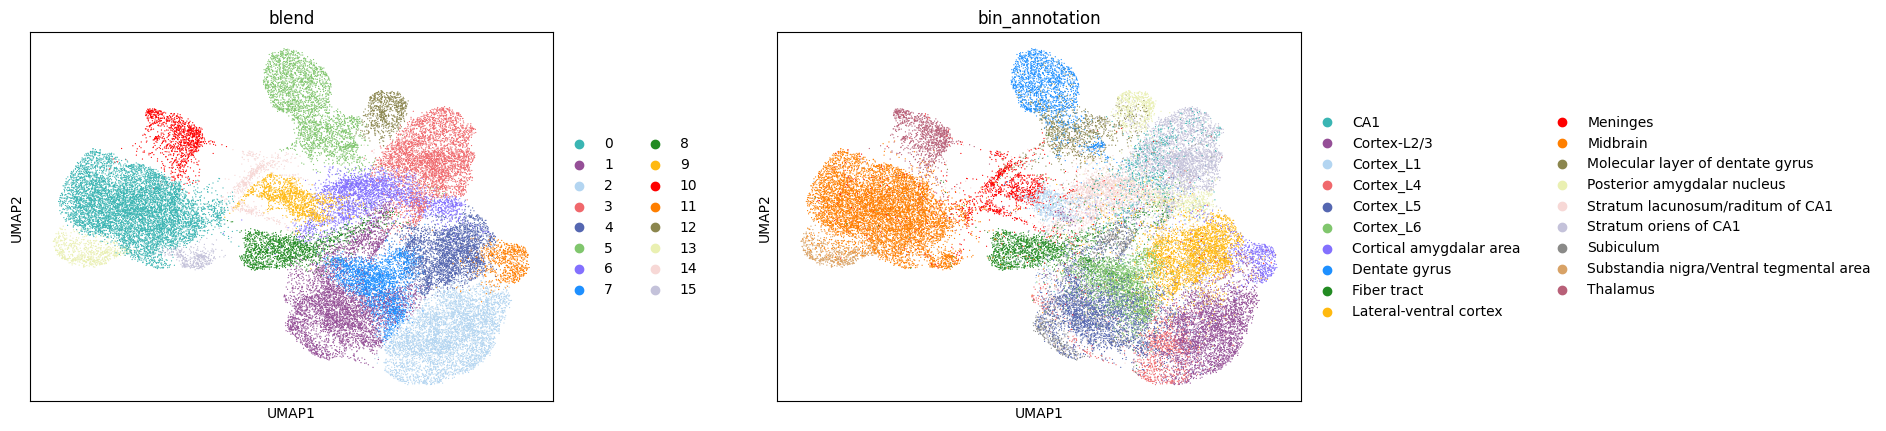

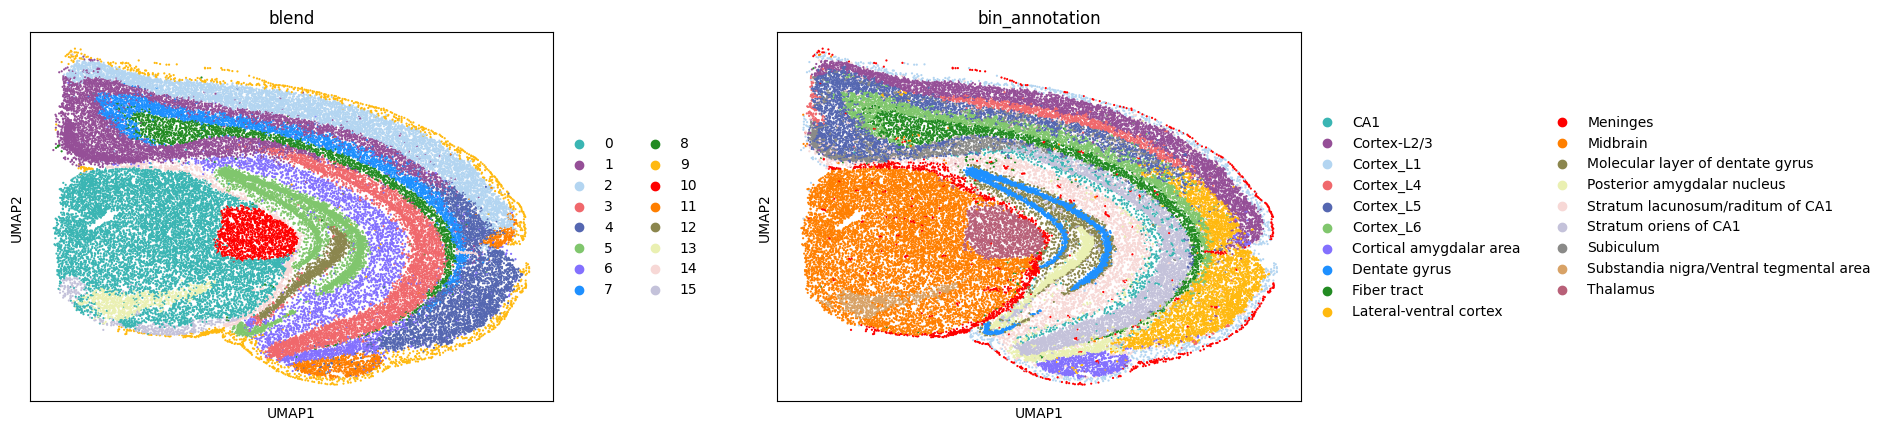

In [15]:
adata.obsm['X_umap'] = X_umap
sc.pl.umap(adata, color=['blend','bin_annotation'], palette=custom_colors, legend_loc='right margin', wspace = 0.3)
adata.obsm['X_umap'] = adata.obsm['spatial']
sc.pl.umap(adata, color=['blend','bin_annotation'], palette=custom_colors, legend_loc='right margin', size=10, wspace = 0.3)